# TP1 - Hopfield

In [1]:
from src.utils import retrieve_patterns
from src.hopfield import Hopfield
from collections import defaultdict

shapes = {}
patterns = {}

for P, shape in retrieve_patterns("images"):
    n = P.shape[1]
    patterns[n] = P
    shapes[n] = shape

models = {}
for n, P in patterns.items():
    models[n] = m = Hopfield(n)
    m.train(P)

Parto el dataset de patrones en 2, entrenando un modelo para cada set de datos con distintos tamaños.

## Imágenes

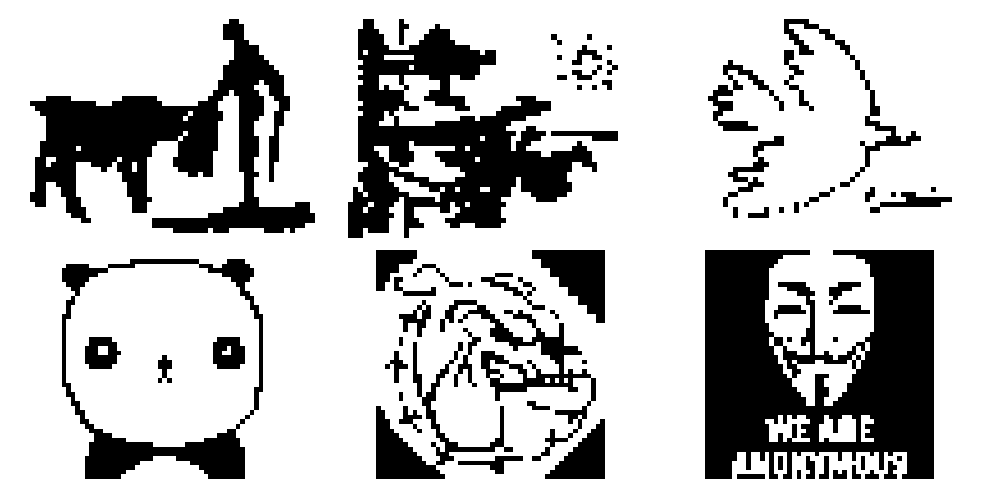

In [2]:
import matplotlib.pyplot as plt
import numpy as np

images = [np.resize(p, shapes[n]) for n, P in patterns.items() for p in P]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 5))

for ax, image in zip(axes.flat, images):
    ax.imshow(image, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 1-a) Verifique si la red aprendió las imágenes enseñadas

In [3]:
for n, m in models.items():
    P = patterns[n]

    for p in P:
        if not m.is_stable(p):
            raise Exception(f"failed to learn pattern")

Dado que no tiró la excepción, podemos confirmar que los patrones son estados estables en sus respectivas redes, osea, las redes aprendieron las imágenes.

## 1-b) Evalúe la evolución de la red al presentarle versiones alteradas de las imágenes aprendidas: agregado de ruido, elementos borrados o agregados.

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from typing import Callable


def recall_metrics(m: Hopfield, p: np.ndarray, p_prime: np.ndarray) -> tuple[int, int]:
    closest, steps = m.recall(p_prime)
    dist = np.sum(closest != p)
    return closest, steps, dist


def plot_metrics(m: Hopfield, P: np.ndarray, f: Callable):
    n = P.shape[1]
    ks = np.arange(0, n + 1, n // 10)
    steps, dists = [0] * len(ks), [0] * len(ks)

    for p in P:
        imgs = []
        for i, k in enumerate(ks):
            closest, steps_taken, dist = recall_metrics(m, p, f(p, min(k, n)))
            imgs.append(np.reshape(closest, shapes[n]))
            steps[i] += steps_taken / len(P)
            dists[i] += dist / len(P)

        fig, axs = plt.subplots(1, 10, figsize=(15, 2))

        for ax, img in zip(axs, imgs):
            ax.imshow(img, cmap="gray")
            ax.axis("off")

        plt.tight_layout()
        plt.show()

    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(20, 7))

    ax0.plot(ks, dists, marker='o')
    ax0.set_title("Hamming distance between original and recalled")
    ax0.set_xlabel("Amount of modified neurons")
    ax0.set_ylabel("Distance (neurons)")
    ax0.set_xticks(ks)
    ax0.grid(True)

    ax1.plot(ks, steps, marker='o')
    ax1.set_title("Steps taken to converge to a stable state")
    ax1.set_xlabel("Amount of modified neurons")
    ax1.set_ylabel("Steps")
    ax1.set_xticks(ks)
    ax1.grid(True)

    fig.suptitle(f"Hopfield Network with {n} neurons", fontsize=14)
    plt.tight_layout()
    plt.show()

Elegí tomar 3 cassos:

- Invertir neuronas
- Setear neuronas a 1
- Setear neuronas a -1

Las imágenes mostradas debajo son los estados resultantes a los patrones modificados dados como entrada. Para cada caso se evaluan los patrones modificando las neuronas de forma creciente, elegí que el step sea tal que hayan 10 medidas. Los gráficos muestran la distancia Hamming promedio entre el patrón original y el resultante y la cantidad de steps promedio de pasadas asincrónicas hasta converger.

#### Neuronas invertidas

Se toma una permutación de k neuronas y se invierten de forma aleatoria.

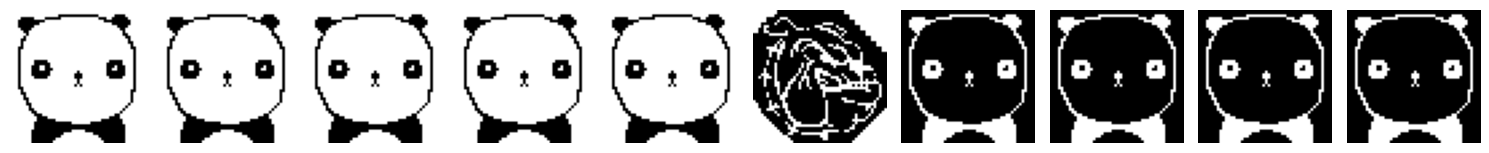

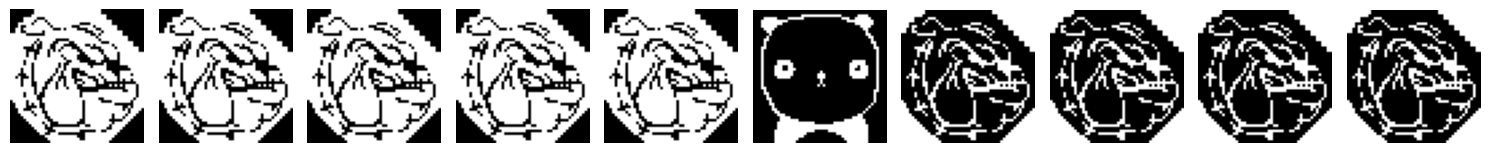

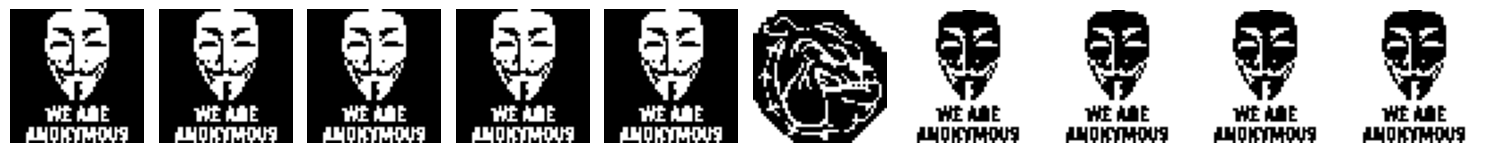

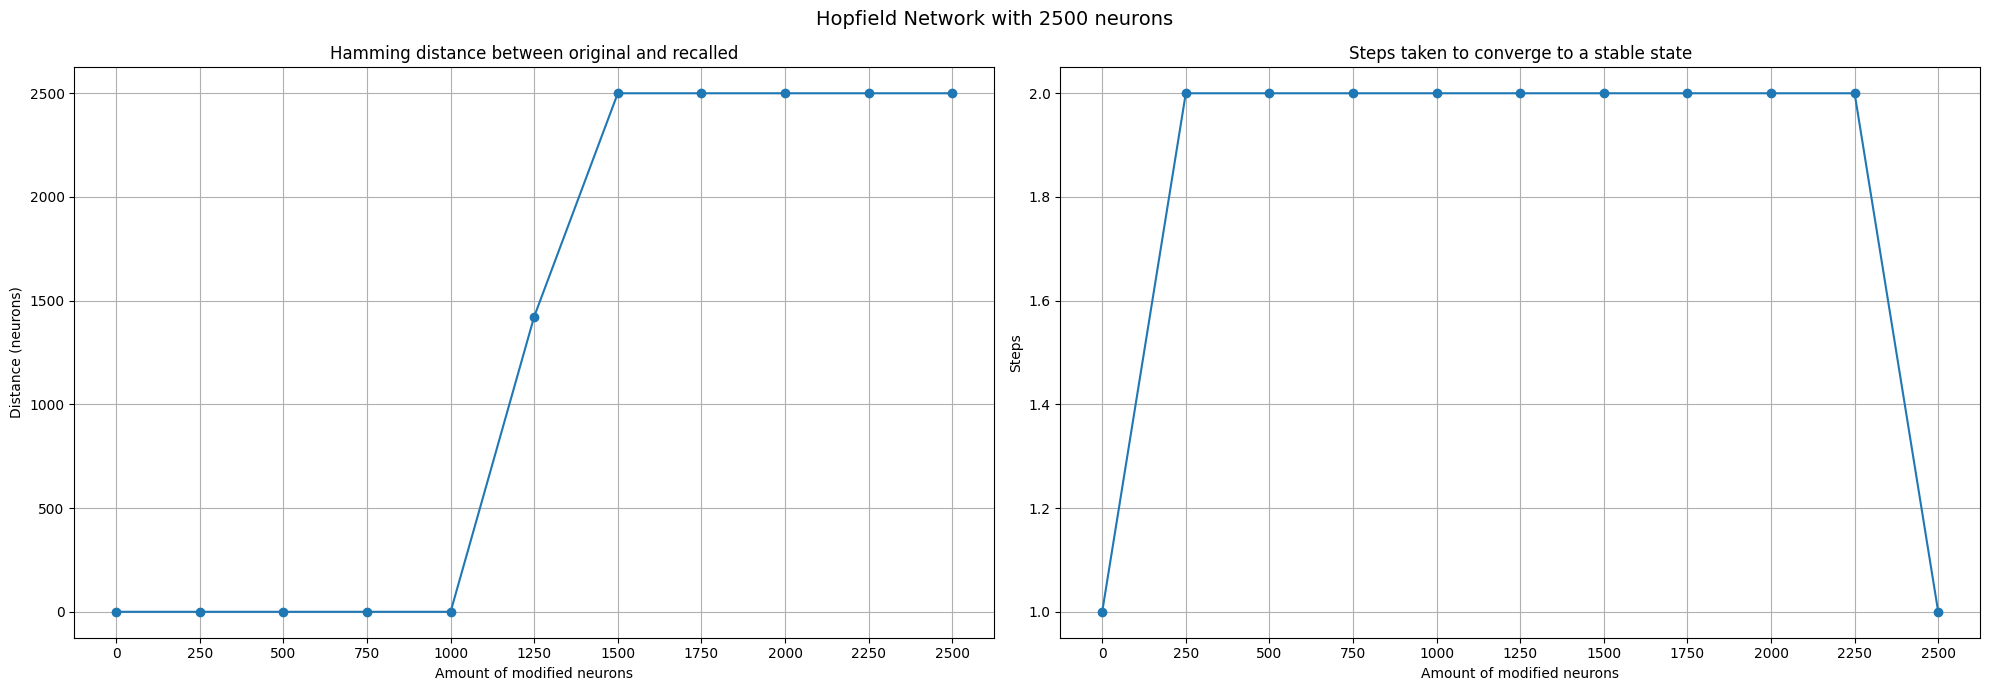

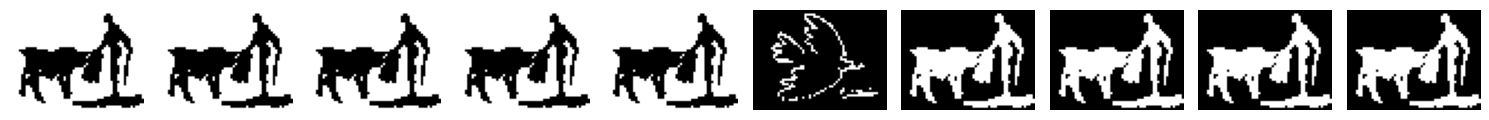

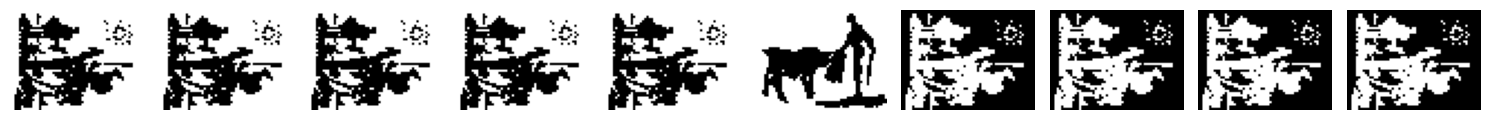

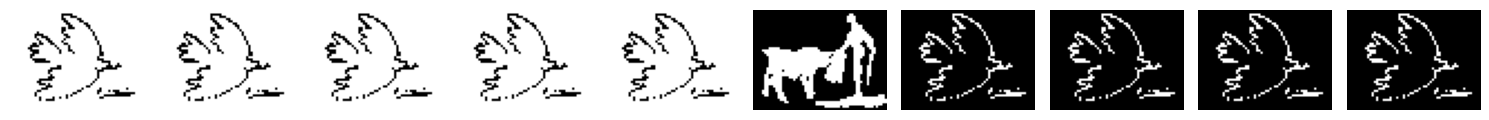

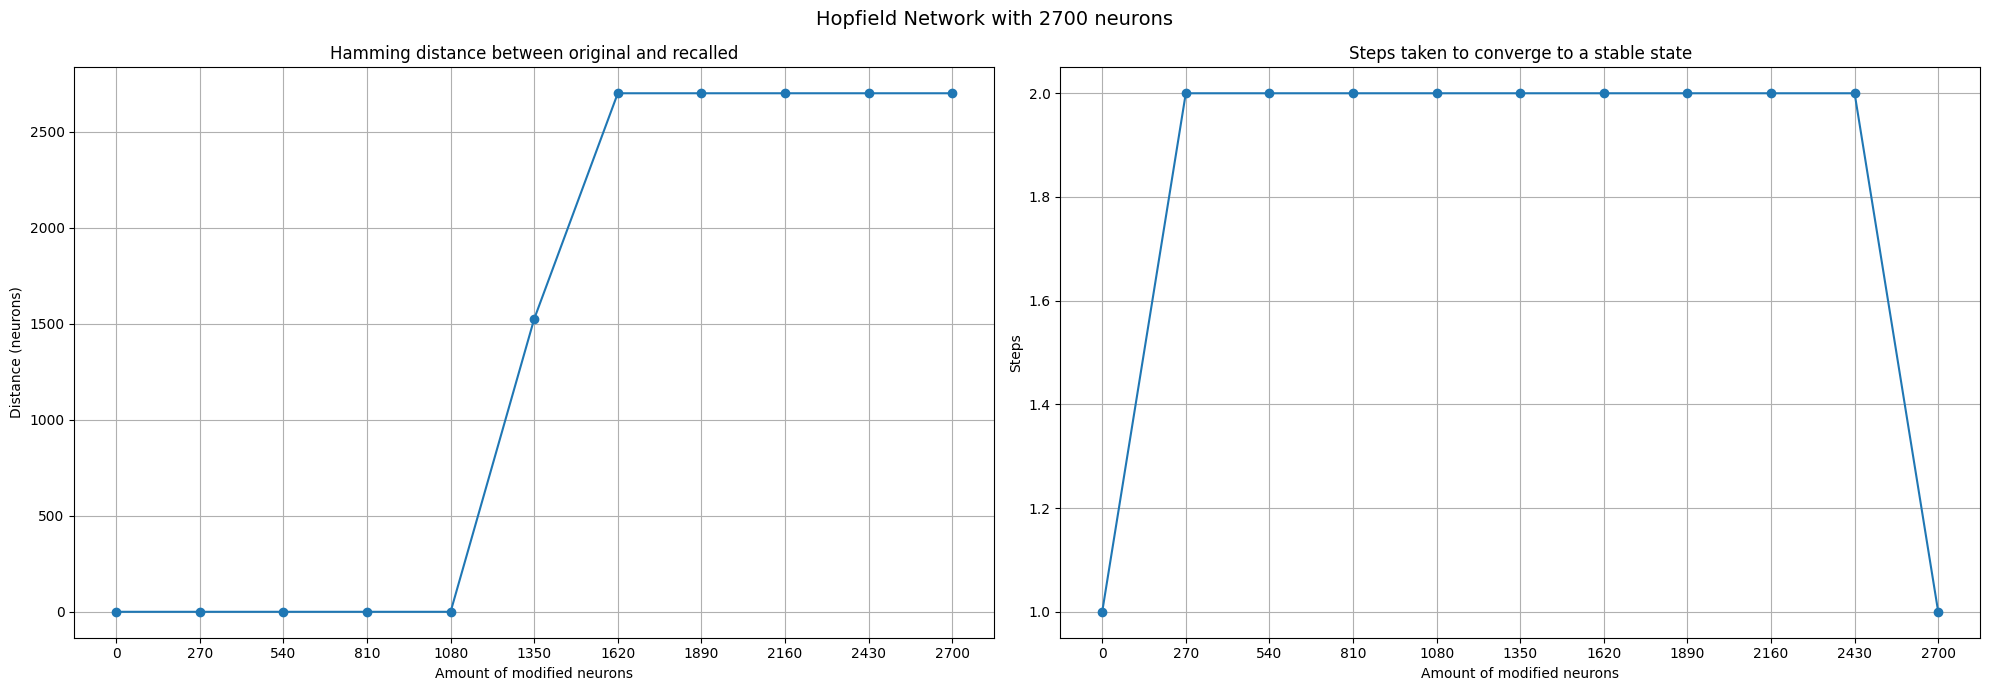

In [5]:
from src.utils import flip_bytes


SEED = 1234

for n in sorted(patterns):
    plot_metrics(models[n], patterns[n], lambda p, k: flip_bytes(p, k, seed=SEED))

#### Neuronas seteadas a 1

Se toman las primeras k neuronas y se setean a 1.

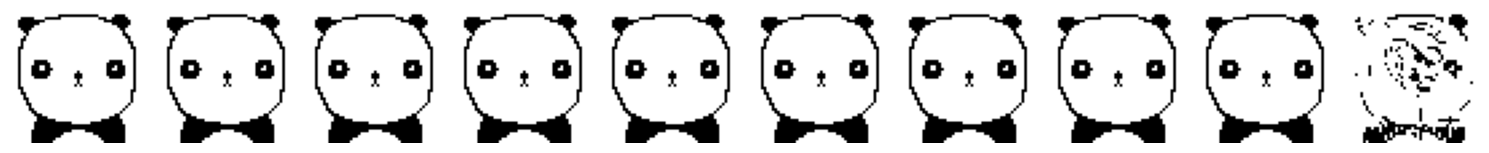

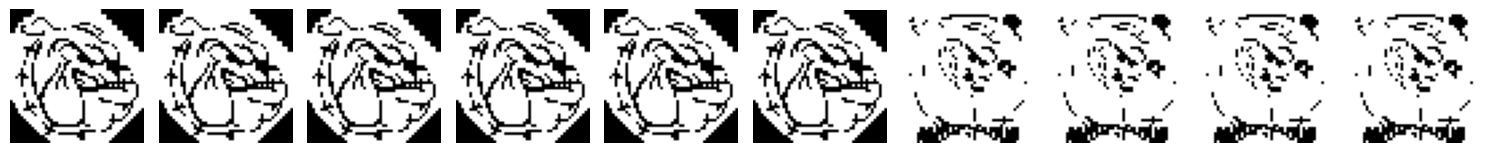

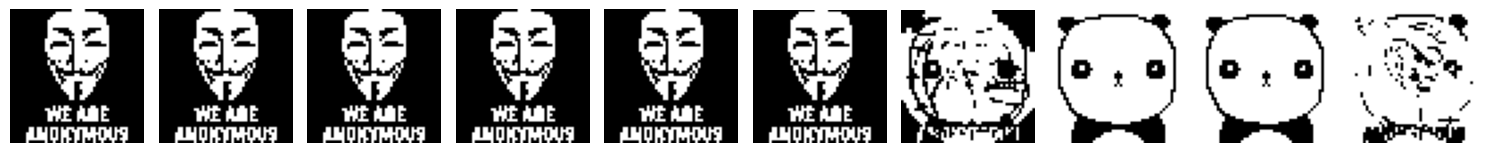

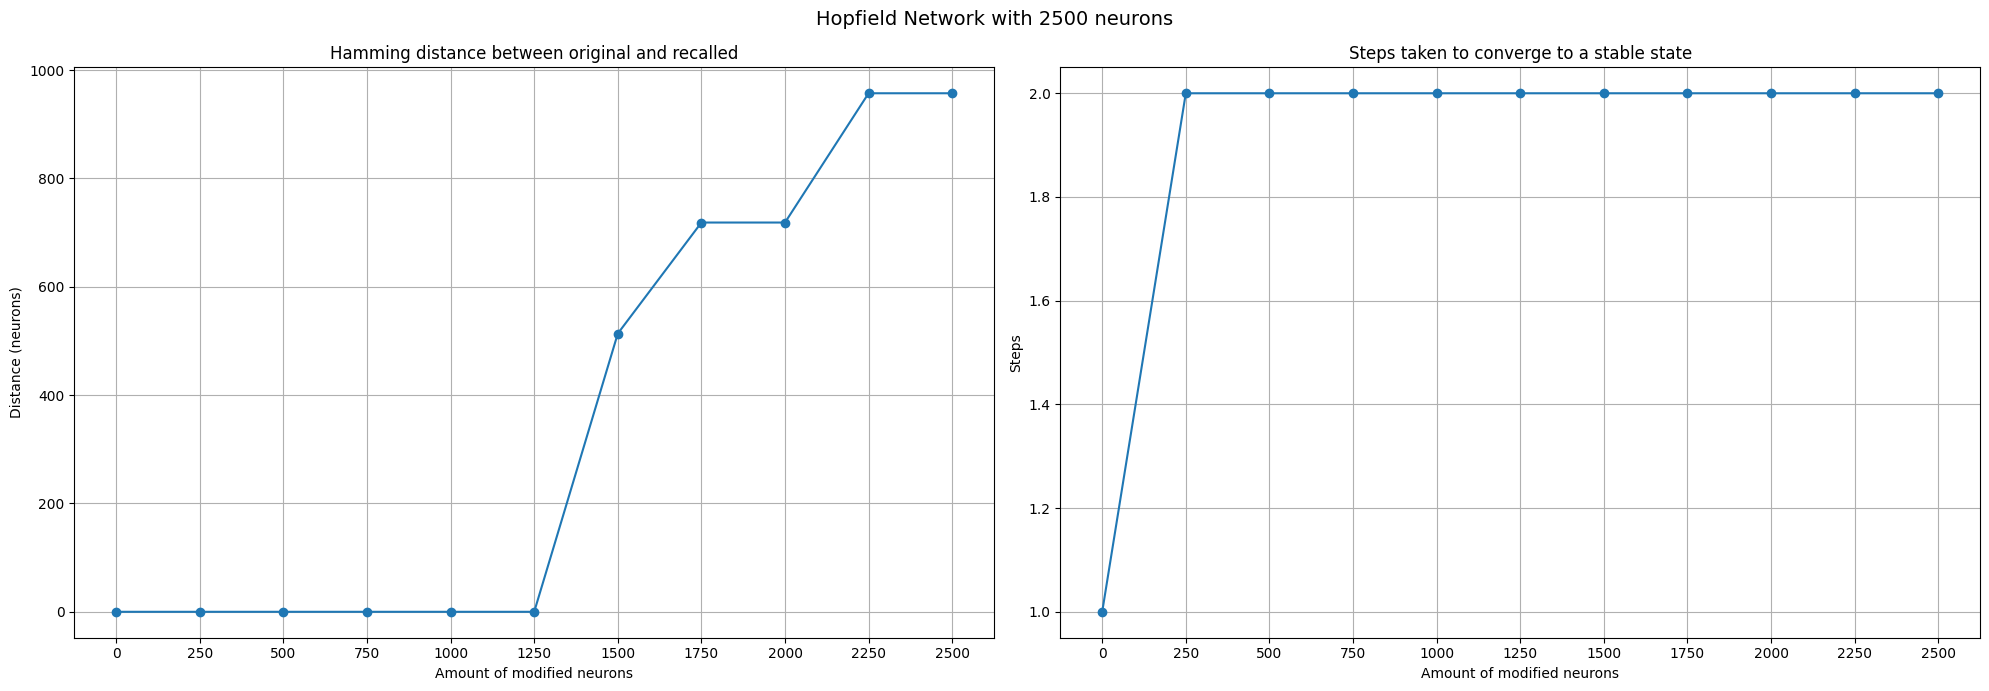

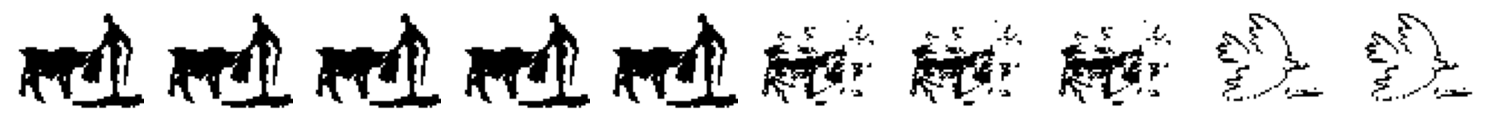

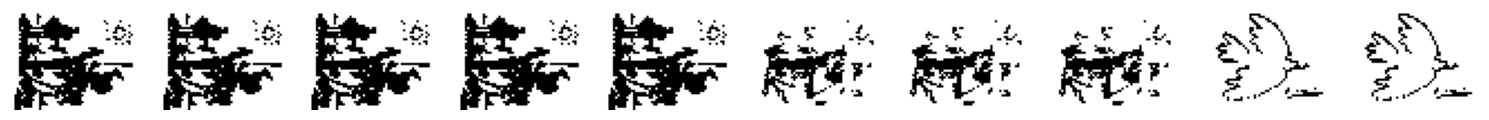

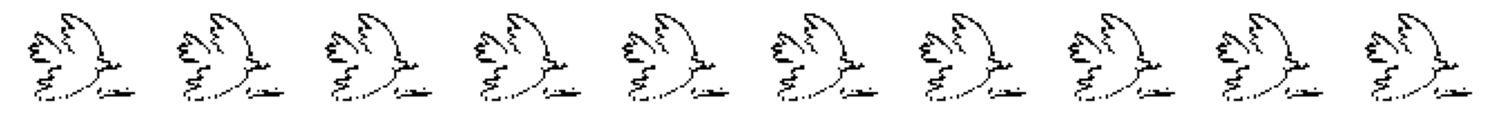

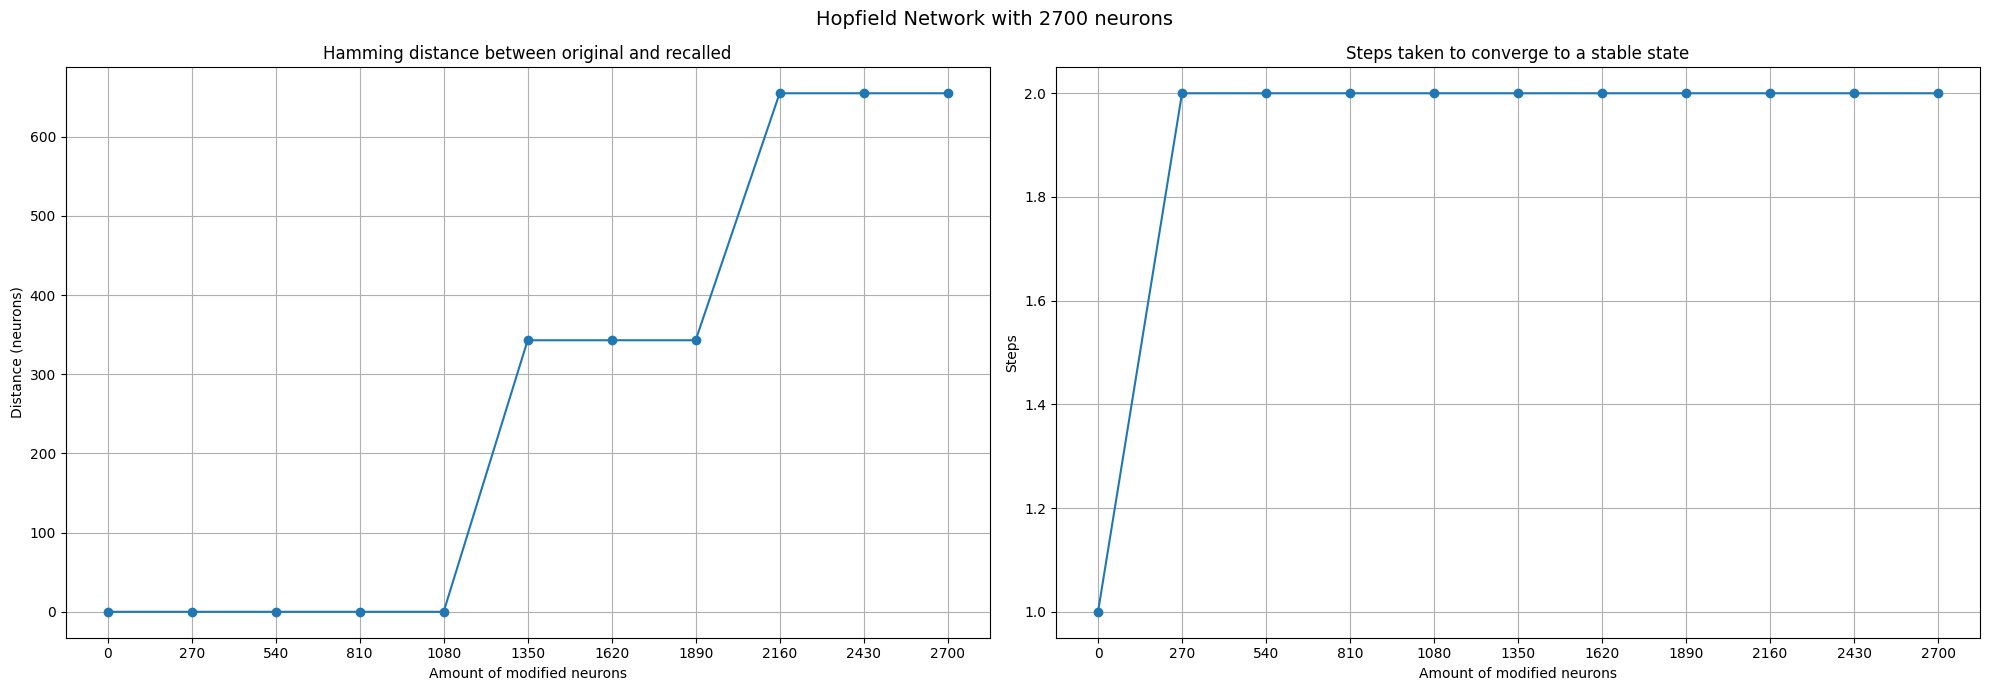

In [6]:
from src.utils import paint_bytes


for n in sorted(patterns):
    plot_metrics(models[n], patterns[n], lambda p, k: paint_bytes(p, k, 1))

#### Neuronas seteadas a -1

Se toman las primeras k neuronas y se setean a -1.

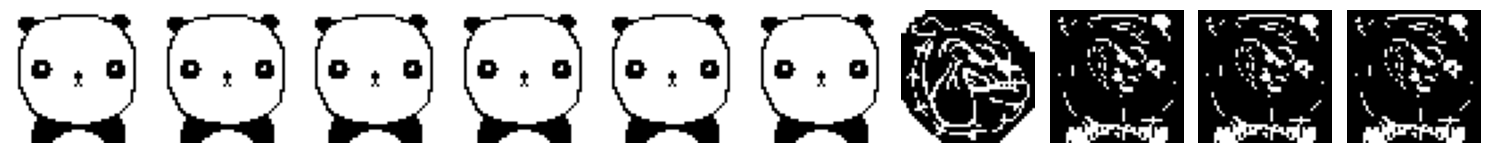

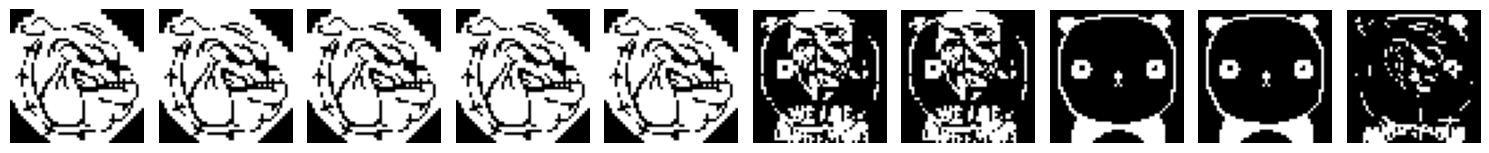

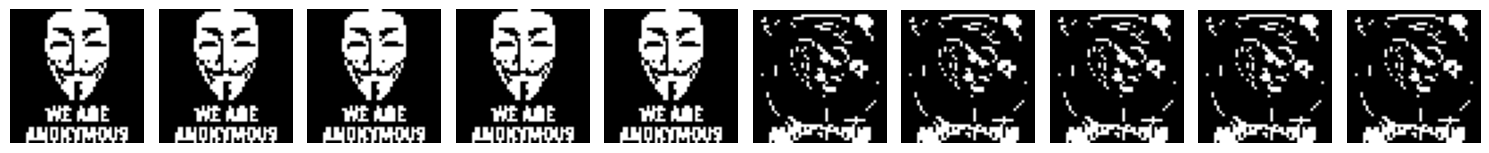

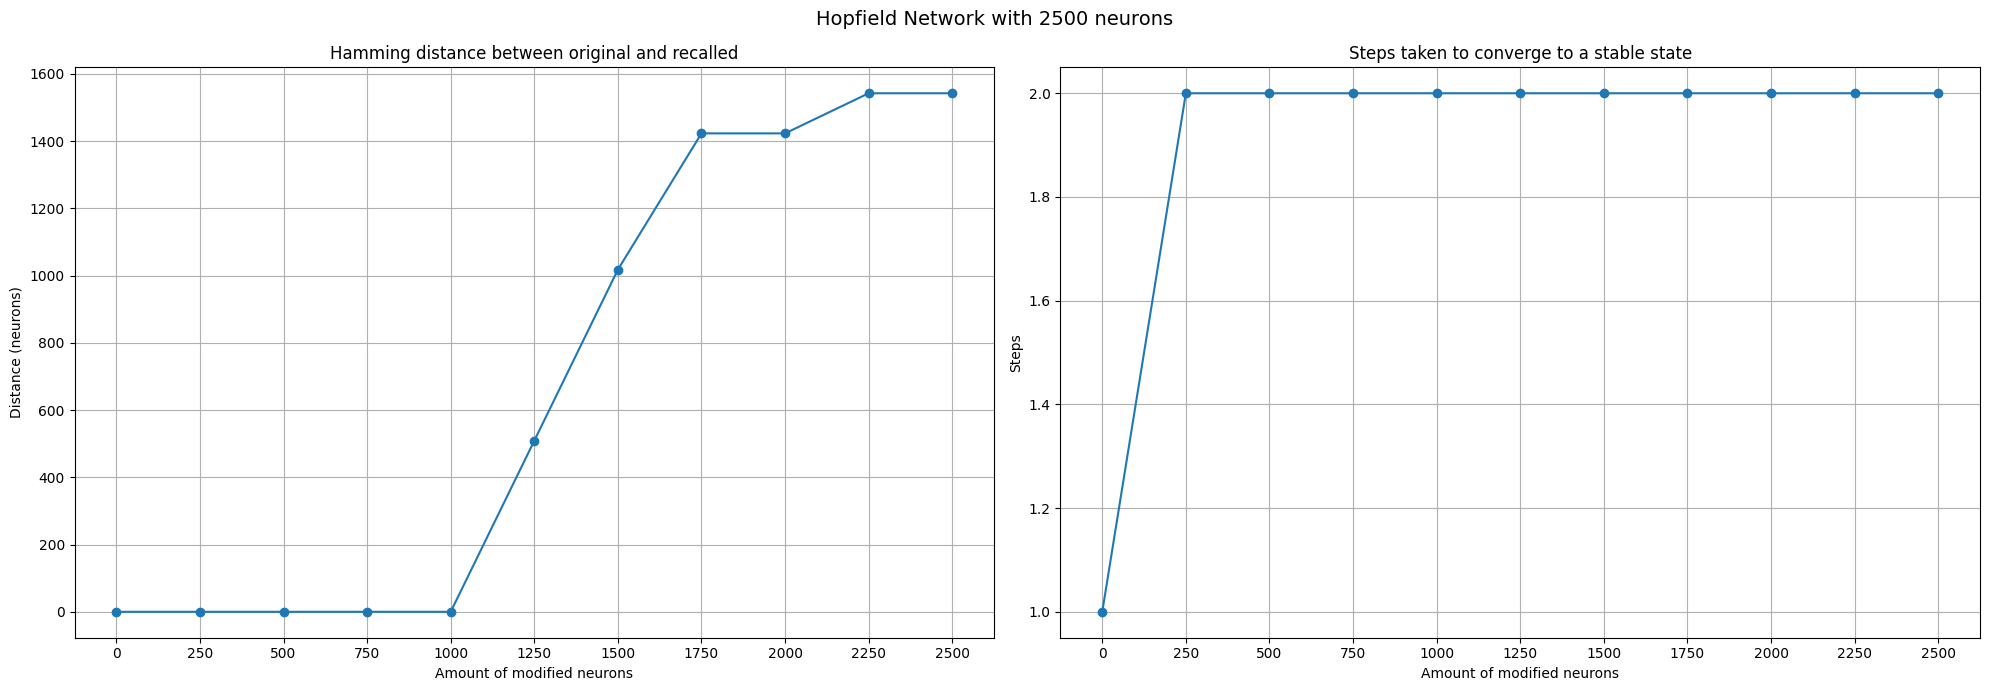

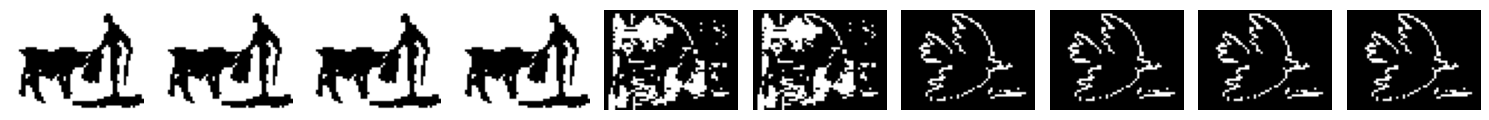

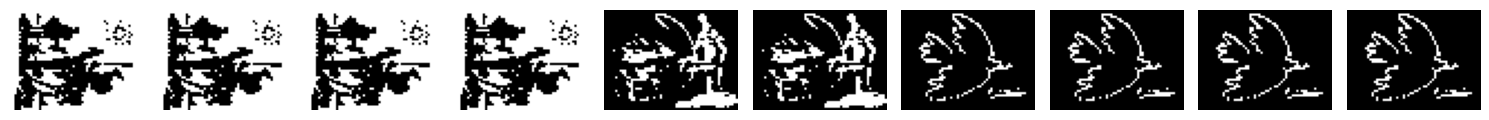

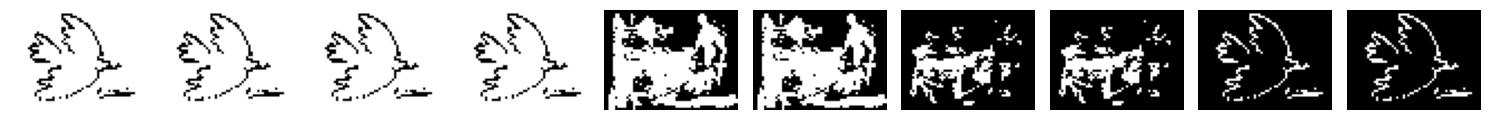

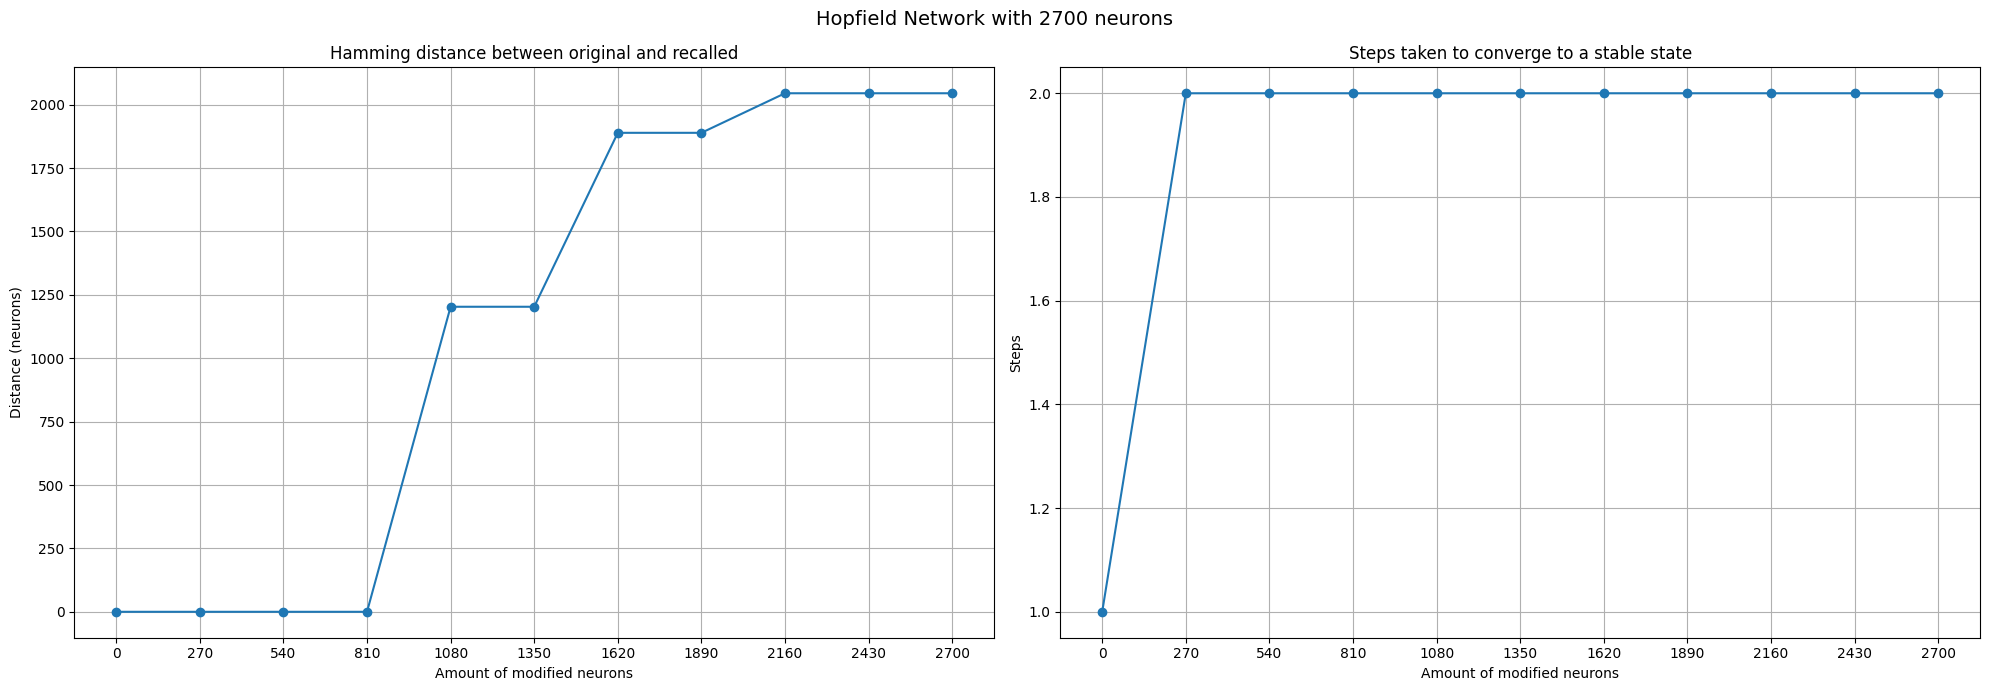

In [7]:
from src.utils import paint_bytes


for n in sorted(patterns):
    plot_metrics(models[n], patterns[n], lambda p, k: paint_bytes(p, k, -1))

Para el caso de invertir neuronas, ambas redes se comportan como esperado, una vez pasado el umbral de la mitad, el atractor inverso es más fuerte que el original, por lo que convergen hacia él.

Para los otros dos casos de tapar las imágenes con algún valor en particular, tienden a caer en otros estados espureos más particulares, se puede ver que algunos de ellos son combinaciones lineales de otros patrones aprendidos.

## 1-c) Evalúe la existencia de estados espurios en la red: patrones inversos y combinaciones de un número impar de patrones. (Ver Spurious States, en la sección 2.2, Hertz, Krogh & Palmer, pág. 24).

In [8]:
import numpy as np
from typing import Iterable


def plot_patterns(Ps: Iterable[np.ndarray], rows: int, cols: int):
    imgs = [np.reshape(p, shapes[len(p)]) for P in Ps for p in P]

    fig, axs = plt.subplots(rows, cols, figsize=(cols << 1, rows << 1))
    axs = np.array(axs).flatten()

    for ax, img in zip(axs, imgs):
        ax.imshow(img, cmap="gray")
        ax.axis("off")
    
    plt.tight_layout()
    plt.show()

#### Patrones inversos

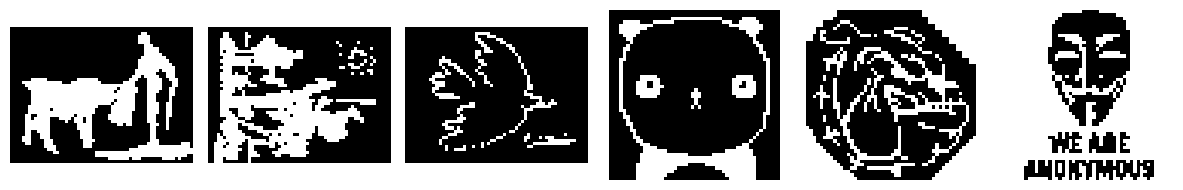

In [9]:
plot_patterns((-P for P in patterns.values()), 1, 6)

for n, m in models.items():
    P = -patterns[n]

    for p in P:
        if not m.is_stable(p):
            raise Exception("Inverse pattern is unstable")

Se aprende todos los patrones inversos.

#### Combinaciones de un número impar de patrones

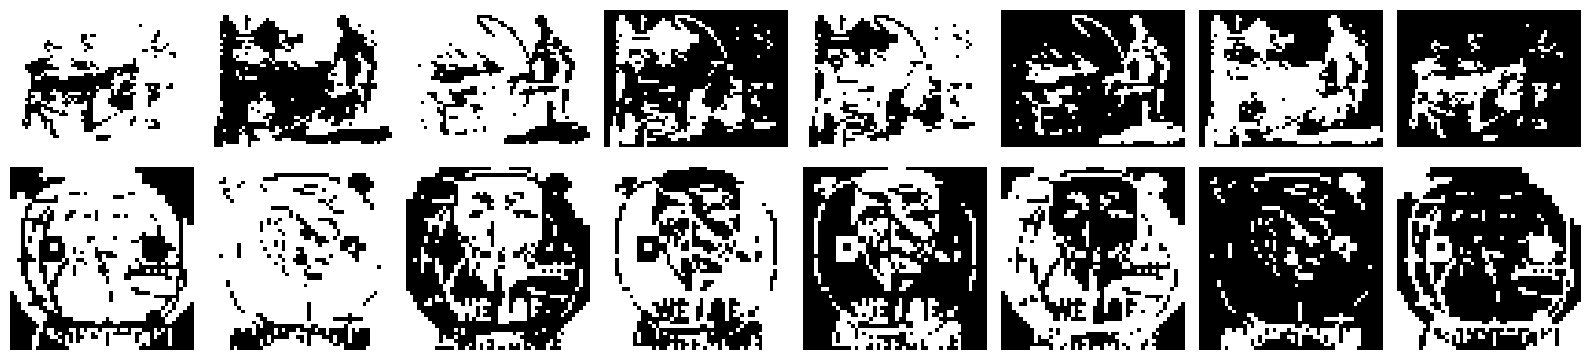

In [10]:
from src.utils import all_linear_combs


plot_patterns((all_linear_combs(P) for P in patterns.values()), 2, 8)

for n, m in models.items():
    combs = all_linear_combs(patterns[n])

    for p in combs:
        if not m.is_stable(p):
            raise Exception("Linear combination is unstable")

Se aprende todos las combinaciones lineales de patrones de 3 imágenes.

## 1-d) Realice un entrenamiento con las 6 imágenes disponibles. ¿Es capaz la red de aprender todas las imágenes? Explique

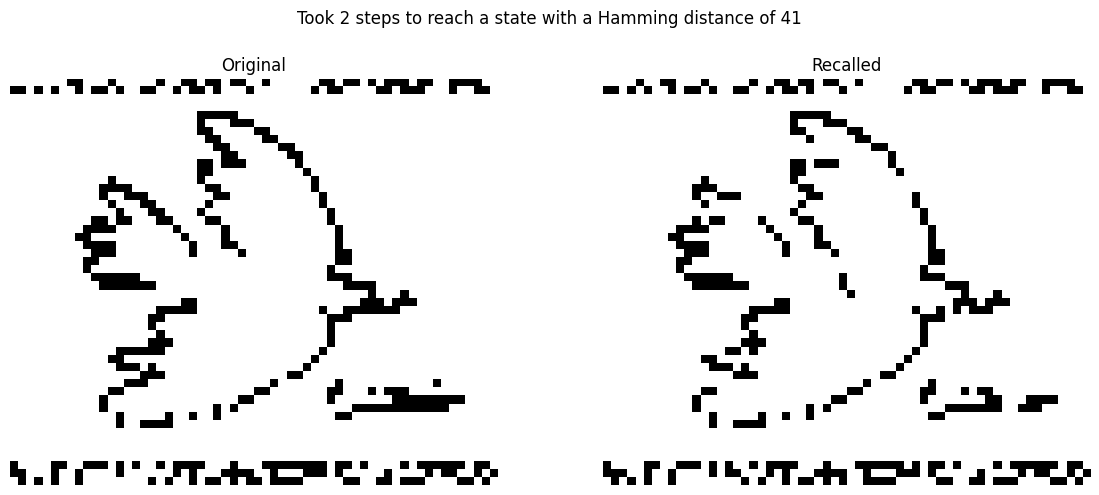

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from src.utils import retrieve_patterns
from typing import Iterable


mheight = max(im.shape[0] for im in images)
mwidth = max(im.shape[1] for im in images)
shape = mwidth, mheight

def plot_if_different(m: Hopfield, p: np.ndarray):
    recalled, steps, dist = recall_metrics(m, p, p)
    if dist == 0:
        return

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    p_arr = p.reshape(shape)
    ax1.imshow((p_arr + 1) // 2, cmap="gray", interpolation="nearest")
    ax1.set_title("Original")
    ax1.axis("off")

    r_arr = recalled.reshape(shape)
    ax2.imshow((r_arr + 1) // 2, cmap="gray", interpolation="nearest")
    ax2.set_title(f"Recalled")
    ax2.axis("off")

    fig.suptitle(f"Took {steps} steps to reach a state with a Hamming distance of {dist}", fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

SEED = 1
P, shape = list(retrieve_patterns("images", shape, seed=SEED))[0]
m = Hopfield(mwidth * mheight)
m.train(P)

for p in P:
    plot_if_different(m, p)

El modelo logra aprender 5 de las 6 imágenes. Elegí agregar un padding aleatorio a cada una de ellas para lograr tener el mismo tamaño en todas e y minimizar la correlación entre las imágenes lo más posible.

Previamente tomé el aproach de paddear las imágenes con un mismo color, esto daba peores resultados haciendo que el pajaro y el quijote convergieran a un estado a ~85 unidades de distancia Hamming.

Entiendo que no logra aprenderlas todas por la capacidad de la red, aunque esta vez es aún más grande que los modelos anteriores, especificamente tiene 3000 neuronas, cosa que los modelos anteriores son de 2500 y 2700. Es verdad que estábamos almacenando 3 patrones en cada uno, esta vez son el doble.

Me sorprende un poco que teniendo tantas neuronas no sea capaz de aprender todos los patrones, aún así el error es bastante chico si tenemos en cuenta que tenemos 3000 neuronas y una distancia de 41 unidades, entonces estamos hablando de un 0.0137% de error.

## 2-a) Comprobar estadísticamente la capacidad de la red de Hopfield ‘82 calculando la cantidad máxima de patrones pseudo-aleatorios aprendidos en función del tamaño de la red. Obtener experimentalmente los resultados de la siguiente tabla (los valores de la tabla corresponden a una iteración con actualización sincrónica).

|P_error|P_max/N|
|-|-|
|0.001|0.105|
|0.0036|0.138|
|0.01|0.185|
|0.05|0.37|
|0.1|0.61|

In [12]:
from src.hopfield import Hopfield
import matplotlib.pyplot as plt
from typing import Callable
import numpy as np


SEED = 1234
rng = np.random.default_rng(SEED)
p_prov = lambda p, n: rng.choice([-1, 1], size=(p, n))
n = 1000

p_errors = [0.001, 0.0036, 0.01, 0.05, 0.1]
p_max_ns_hertz = [0.105, 0.138, 0.185, 0.37, 0.61]
p_max_ns_aprox = [Hopfield.capacity(n, p_error, p_prov) / n for p_error in p_errors]

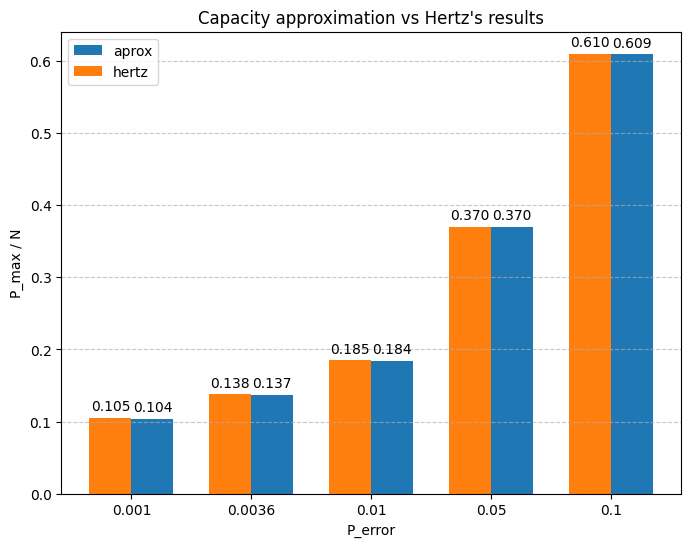

In [13]:
x = np.arange(len(p_errors))
bar_width = 0.35

plt.figure(figsize=(8, 6))

bars1 = plt.bar(x + bar_width / 2, p_max_ns_aprox, bar_width, label='aprox')
bars2 = plt.bar(x - bar_width / 2, p_max_ns_hertz, bar_width, label='hertz')

plt.xticks(x, p_errors)
plt.xlabel("P_error")
plt.ylabel("P_max / N")
plt.title("Capacity approximation vs Hertz's results")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.bar_label(bars1, fmt="%.3f", padding=3)
plt.bar_label(bars2, fmt="%.3f", padding=3)
plt.show()

Calculando los las capacidades de forma numerica para distintos errores vemos que da bastante parecido para todos ellos. A medida que incrementamos la cantidad de neuronas los patrones van a tender a ser todavía más uniformes, haciendo que el error se acerque cada vez más.

Con 1000 neuronas creo yo que da bastante bien y se calcula relativamente rápido.

## 2-b) Proponga una manera de generar patrones con distintos grados de correlación. Utilice el método propuesto para analizar cómo varía la capacidad de la red de Hopfield en función de la correlación entre patrones.

### Generación de patrones correlacionados

Sea \(N\) el número de neuronas. Queremos que la correlación promedio entre patrones distintos sea $\rho \in [0,1]$.

**1. Elegir un prototipo**

$$
\mathbf{g} \in \{-1,+1\}^N, \quad \text{con cada } g_i \text{ elegido al azar.}
$$

**2. Determinar la probabilidad de copiar cada bit**

$$
q = \frac{1 + \sqrt{\rho}}{2}, \quad p_\text{flip} = 1 - q
$$

**3. Generar cada patrón**

Para cada patrón $x^{(a)}$, y para cada neurona $i$:

$$
x^{(a)}_i =
\begin{cases}
g_i, & \text{con probabilidad } q \\
-g_i, & \text{con probabilidad } 1-q
\end{cases}
$$

**4. Propiedad**

La correlación empírica entre patrones diferentes $x^{(a)}$ y $x^{(b)}$ es aproximadamente

$$
\frac{1}{N} \sum_{i=1}^N x^{(a)}_i x^{(b)} \approx \rho
$$

- $\rho = 0$ → patrones independientes  
- $\rho = 1$ → patrones idénticos


In [14]:
from src.hopfield import Hopfield
import numpy as np


SEED = 1234
rng = np.random.default_rng(SEED)

def prov(p: int, n: int, corr: float) -> np.ndarray:
    g = rng.choice([-1, 1], size=n)
    q = 0.5 * (1.0 + np.sqrt(corr))
    flips = rng.random((p, n)) < (1 - q)
    return np.where(flips, -g, g)

corrs = np.linspace(0.0, 1.0, 11)
p_max_ns = []
p_error = 0.0036
n = 1000

for corr in corrs:
    p_prov = lambda p, n: prov(p, n, corr)
    p_max_n = Hopfield.capacity(n, p_error, p_prov) / n
    p_max_ns.append(p_max_n)

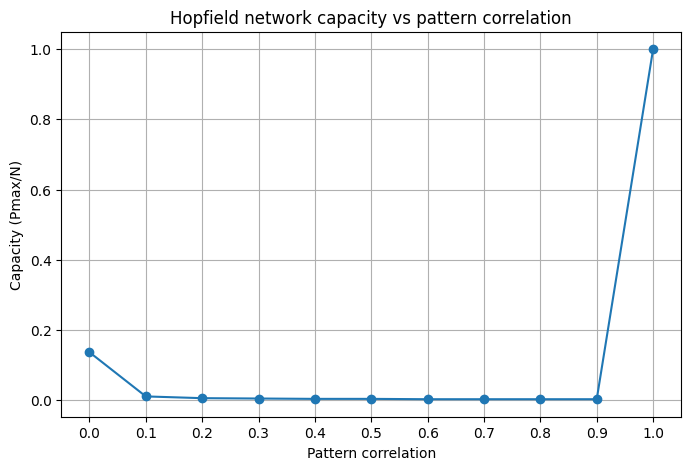

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(corrs, p_max_ns, marker='o')
plt.xlabel("Pattern correlation")
plt.ylabel("Capacity (Pmax/N)")
plt.title("Hopfield network capacity vs pattern correlation")
plt.xticks(corrs)
plt.grid(True)
plt.show()

Rápidamente la capacidad de la red cae una vez que correlacionamos los patrones.

El aumento de la capacidad para el valor más alto se debe a que los patrones generados aleatoriamente con correlación de 1.0 son en realidad el mismo patrón, haciendo que entrenar una nueva imágen agrande al mismo atractor, entonces verificar si aprendió la imágen va a dar siempre que sí.

## 3. Implemente una red de Hopfield ‘82 que aprenda patrones pseudo-aleatorios y estudie qué sucede con los patrones aprendidos cuando algunas interconexiones son eliminadas al azar.

## a) ¿Cómo cambia el error en función del porcentaje de sinapsis eliminadas?

In [16]:
from src.hopfield import Hopfield
import numpy as np

n = 1000
SEED = 1234
rng = np.random.default_rng(SEED)
P = rng.choice([1, -1], size=(20, n))

m = Hopfield(n)
m.train(P)

partitions = 100
idxs = np.array([(i, j) for i in range(n) for j in range(n) if i != j])
rng.shuffle(idxs)
chunks = np.array_split(idxs, partitions)
errors = []

for chunk in chunks:
    for i, j in chunk:
        m.W[i][j] = 0.0

    S = np.where(P @ m.W >= 0.0, 1, -1)
    error = np.mean(S != P)
    errors.append(error)

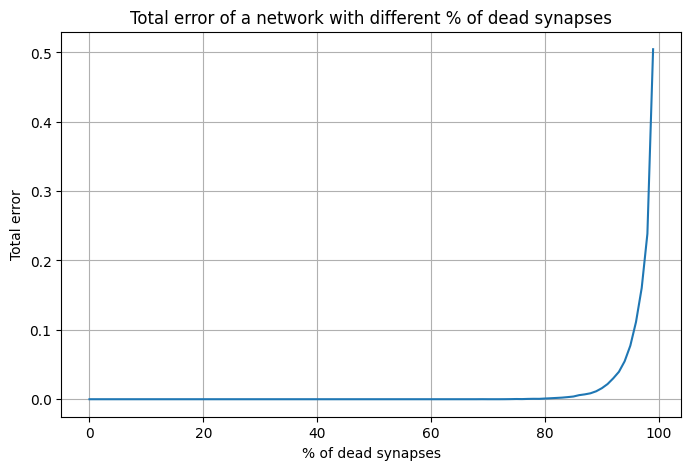

In [17]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))
plt.plot(errors)
plt.xlabel("% of dead synapses")
plt.ylabel("Total error")
plt.title("Total error of a network with different % of dead synapses")
plt.grid(True)
plt.show()

El error no parece ser muy alterado hasta no matar más del 80% de las conexiones, donde de golpe crece de forma exponencial hasta alcanzar 0.5.

## 3-b) ¿Cómo cambia la capacidad en función del porcentaje de sinapsis eliminadas

In [18]:
from src.hopfield import Hopfield
import numpy as np


SEED = 1234
rng = np.random.default_rng(SEED)

n = 500
idxs = np.array([(i, j) for i in range(n) for j in range(n) if i != j])
rng.shuffle(idxs)

partitions = 100
chunks = np.array_split(idxs, partitions)

p_error = 0.01
p_prov = lambda p, n: rng.choice([1, -1], size=(p, n))
M = np.ones((n, n))
capacities = []

for chunk in chunks:
    for i, j in chunk:
        M[i][j] = 0.0

    capacity = Hopfield.capacity(n, p_error, p_prov, mask=M)
    capacities.append(capacity)

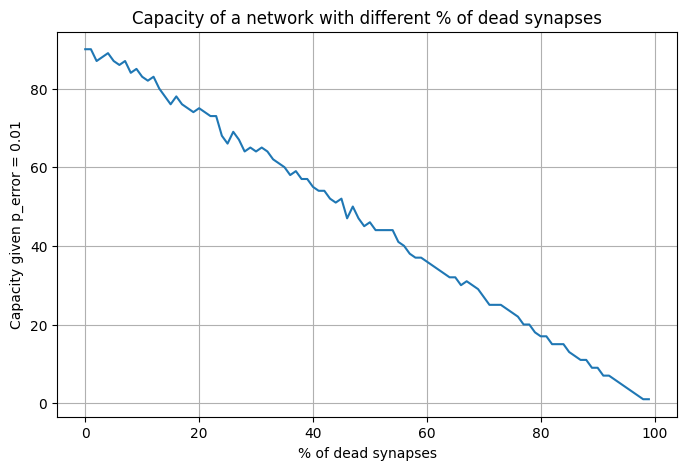

In [19]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))
plt.plot(capacities)
plt.xlabel("% of dead synapses")
plt.ylabel(f"Capacity given p_error = {p_error}")
plt.title("Capacity of a network with different % of dead synapses")
plt.grid(True)
plt.show()

Parece que la tendencia de la capacidad es lineal decresciente, lo que contrasta contra el error que crece de forma no lineal.